**Importing Useful Libraries**

In [2]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    endpoint_url=endpoint, # MinIO API endpoint
    aws_access_key_id=access_key, # User name
    aws_secret_access_key=secret_key, # Password
)

In [3]:
def uplod_csv(df, bucket_name, object_name, path="temporal-landing/", metadata=None):
    # Convert DataFrame to CSV in memory
    csv_buffer = StringIO()
    df.to_csv(csv_buffer, index=False)

    row_count, column_count = df.shape
    target_key = f"{path}{object_name}"
    print(f"[CSV upload batch] preparing {object_name}: rows={row_count:,}, columns={column_count}, target=s3://{bucket_name}/{target_key}")

    # Upload CSV to MinIO
    s3.put_object(
        Bucket=bucket_name,
        Key=target_key,
        Body=csv_buffer.getvalue(),
        Metadata=metadata
    )

    print(f"[CSV upload batch] uploaded s3://{bucket_name}/{target_key}")

**Global Warming Dataset (Structured)**

In [4]:
gwd_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ankushpanday1/global-warming-dataset-195-countries-1900-2023",
  "global_warming_dataset.csv"
)
print("First 5 records:", gwd_df.head())

/tmp/ipykernel_1044/4068025393.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  gwd_df = kagglehub.load_dataset(


First 5 records:        Country  Year  Temperature_Anomaly  CO2_Emissions    Population  \
0  Country_103  1913            -1.163537   8.876061e+08  1.627978e+08   
1  Country_180  1950            -0.432122   4.497517e+08  4.281359e+08   
2   Country_93  2014             0.444954   4.579080e+08  4.926732e+08   
3   Country_15  2020            -1.171616   5.049503e+08  1.252169e+09   
4  Country_107  1964            -0.564038   6.898891e+08  2.932960e+08   

   Forest_Area           GDP  Renewable_Energy_Usage  Methane_Emissions  \
0    54.872178  6.139887e+12               76.710013       8.317626e+06   
1    84.051006  2.601447e+12               68.450021       6.206540e+06   
2    72.295357  5.192677e+12               36.725699       1.056885e+06   
3    17.259684  8.252128e+12               77.547901       1.986813e+06   
4    44.438605  8.560746e+12               10.019576       3.313252e+06   

   Sea_Level_Rise  ...  Waste_Management  Per_Capita_Emissions  \
0        8.111839  ..

In [6]:
print("[CSV upload batch 1/4] global_warming_dataset")
# Upload to MinIO
uplod_csv(gwd_df, "landing-zone", "global_warming_dataset.csv",
    metadata={"source": "kaggle",
              "url": "https://www.kaggle.com/datasets/ankushpanday1/global-warming-dataset-195-countries-1900-2023"}
)

[CSV upload batch 1/4] global_warming_dataset
[CSV upload batch] preparing global_warming_dataset.csv: rows=100,000, columns=26, target=s3://landing-zone/temporal-landing/global_warming_dataset.csv
[CSV upload batch] uploaded s3://landing-zone/temporal-landing/global_warming_dataset.csv


This dataset captures the details of how CO2 emissions by a vehicle can vary with the different features. The dataset has been taken from Canada Government official open data website. This is a compiled version. This contains data over a period of 7 years. There are total 7385 rows and 12 columns. There are few abbreviations that has been used to describe the features. Link: `https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles`

In [8]:
co2_df.shape

(7385, 12)

**Temperature Change (Structured)**

In [10]:
# Use dataset_download and explicitly select the FAOSTAT CSV used by the project
path = kagglehub.dataset_download("sevgisarac/temperature-change")
target_file = "FAOSTAT_data_en_11-1-2024.csv"
csv_path = os.path.join(path, target_file)
if not os.path.exists(csv_path):
    available_files = sorted(f for f in os.listdir(path) if f.endswith('.csv'))
    raise FileNotFoundError(f"Expected {target_file} in {path}. Available CSV files: {available_files}")
# Load with the encoding we identified earlier
tc_df = pd.read_csv(csv_path, encoding="latin-1")
print(f"Loaded file: {target_file}")
print(tc_df.head())

Loaded file: FAOSTAT_data_en_11-1-2024.csv
  ï»¿Domain Code                      Domain  Area Code (M49)         Area  \
0             ET  Temperature change on land                4  Afghanistan   
1             ET  Temperature change on land                4  Afghanistan   
2             ET  Temperature change on land                4  Afghanistan   
3             ET  Temperature change on land                4  Afghanistan   
4             ET  Temperature change on land                4  Afghanistan   

   Element Code             Element  Months Code   Months  Year Code  Year  \
0          7271  Temperature change         7001  January       1961  1961   
1          7271  Temperature change         7001  January       1962  1962   
2          7271  Temperature change         7001  January       1963  1963   
3          7271  Temperature change         7001  January       1964  1964   
4          7271  Temperature change         7001  January       1965  1965   

  Unit  Value Flag 

In [12]:
print("[CSV upload batch 3/4] temperature_change")
# Upload to MinIO
uplod_csv(tc_df, "landing-zone", "temperature_change.csv",
    metadata={"source": "kaggle",
              "url": "https://www.kaggle.com/datasets/sevgisarac/temperature-change"}
)

[CSV upload batch 3/4] temperature_change
[CSV upload batch] preparing temperature_change.csv: rows=241,893, columns=14, target=s3://landing-zone/temporal-landing/temperature_change.csv
[CSV upload batch] uploaded s3://landing-zone/temporal-landing/temperature_change.csv


The Natural Disaster Tweets dataset available on Hugging Face contains a collection of Twitter posts related to natural disasters, such as hurricanes, floods, and wildfires. It includes 127,593 tweets, where each record contains the text of the tweet and a label indicating the disaster type or category. Link: `https://huggingface.co/datasets/nlp-pw/Natural_disaster_tweets`

In [14]:
ndt_df.shape

(127593, 5)

**Weather Image Recognition (Unstructured)**

Number of categories: 11
[image discovery batch 1/11] category=frost, images=475
[image discovery batch 2/11] category=lightning, images=377
[image discovery batch 3/11] category=rime, images=1160
[image discovery batch 4/11] category=snow, images=621
[image discovery batch 5/11] category=fogsmog, images=851
[image discovery batch 6/11] category=rain, images=526
[image discovery batch 7/11] category=dew, images=698
[image discovery batch 8/11] category=sandstorm, images=692
[image discovery batch 9/11] category=hail, images=591
[image discovery batch 10/11] category=rainbow, images=232
[image discovery batch 11/11] category=glaze, images=639


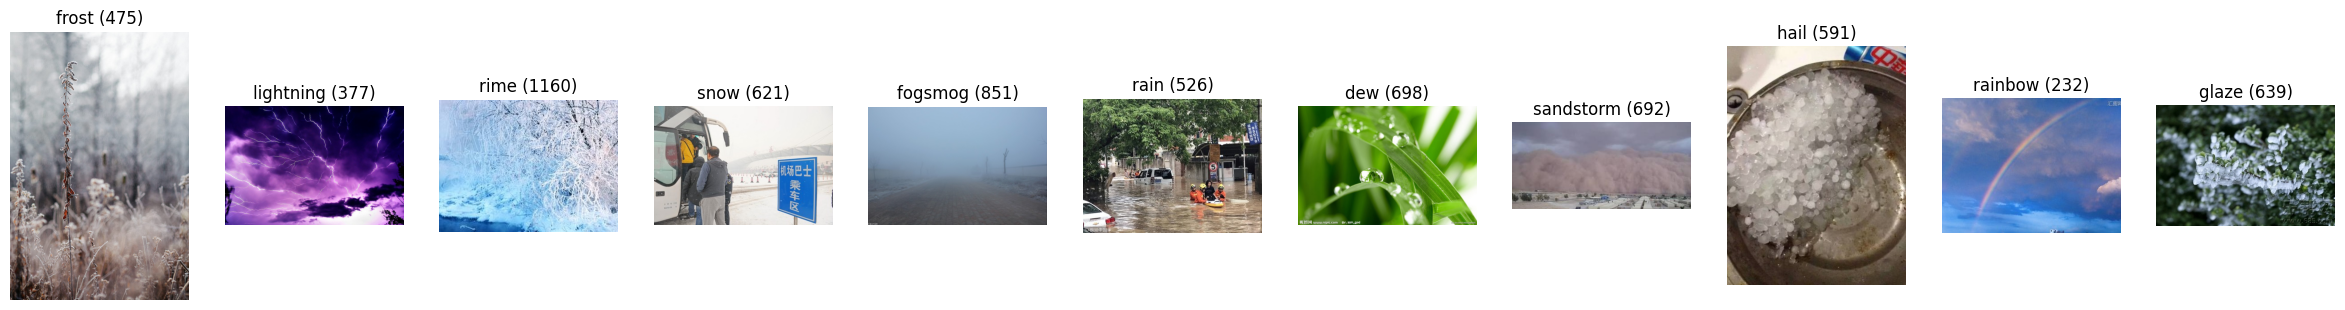

Total number of images: 6862


In [16]:
# 1. Download the dataset
path = kagglehub.dataset_download("jehanbhathena/weather-dataset")
root_path = path + "/dataset"
# 2. Show the number of categories
categories = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]
print(f"Number of categories: {len(categories)}")
# 3. Show the first image of each category
total_images = 0
plt.figure(figsize=(30, 10))
for i, category in enumerate(categories):
    category_path = os.path.join(root_path, category)
    files = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Count images in this category
    num_images = len(files)
    total_images += num_images
    print(f"[image discovery batch {i + 1}/{len(categories)}] category={category}, images={num_images}")
    if not files:
        print(f"[image discovery batch {i + 1}/{len(categories)}] skipped empty category={category}")
        continue
    # Show first image
    file_path = os.path.join(category_path, files[0])
    img = Image.open(file_path)
    plt.subplot(1, len(categories), i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{category} ({num_images})")
plt.show()
print(f"Total number of images: {total_images}")